# Estudio de algoritmos basados en Upper Confidence Bounds en el problema k-armed bandits

*Description:* El experimento compara el rendimiento de algoritmos UCB en un problema de k-armed bandit. Se estudian los algoritmos UCB1 y UCB2, se generan distintas gráficas para evaluar la eficacia de ambos.

    Authors: Ginés Carrillo Ibáñez, Yago Ibarrola Lapeña, Aarón Palomar Peña
    Emails: gines.carrilloi@um.es, yago.ibarrolal@um.es, aaron.p.p@um.es
    Date: 2026/02/06

## Preparación del entorno

In [1]:
#!git clone https://github.com/YagoIbarrola/EML_Carrillo_Ibarrola_Palomar.git
#!cd k_brazos/

In [2]:
import sys
sys.path.append('/content/k_brazos/src')

In [3]:
from algorithms import UCB1, UCB2
from arms import ArmNormal, ArmBernoulli, ArmBinomial, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret
from utils import run_experiment

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
seed = 42
np.random.seed(seed)

## Ejecución del experimento

Se realizan tres experimentos, evaluando en cada uno de ellos los rendimientos de los algoritmos UCB1 y UCB2 para varios valores de sus parámetros. las pruebas de los dos algoritmos de UCB en tres distribuciones: normal, binomial y Bernoulli

### Experimento 1: Distribución normal

In [5]:
k = 10  # Número de brazos
steps = 1000  # Número de pasos
runs = 500  # Número de ejecuciones

Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56


c:\Users\Usuario\OneDrive\Desktop\MASTER\2do CUATRI\EML\Practicas\EML_MASTER\k_brazos\src\algorithms\ucb2.py:71: RuntimeWarning: invalid value encountered in sqrt
  ucb_values[a] = mean_reward + np.sqrt(numerator / denominator)


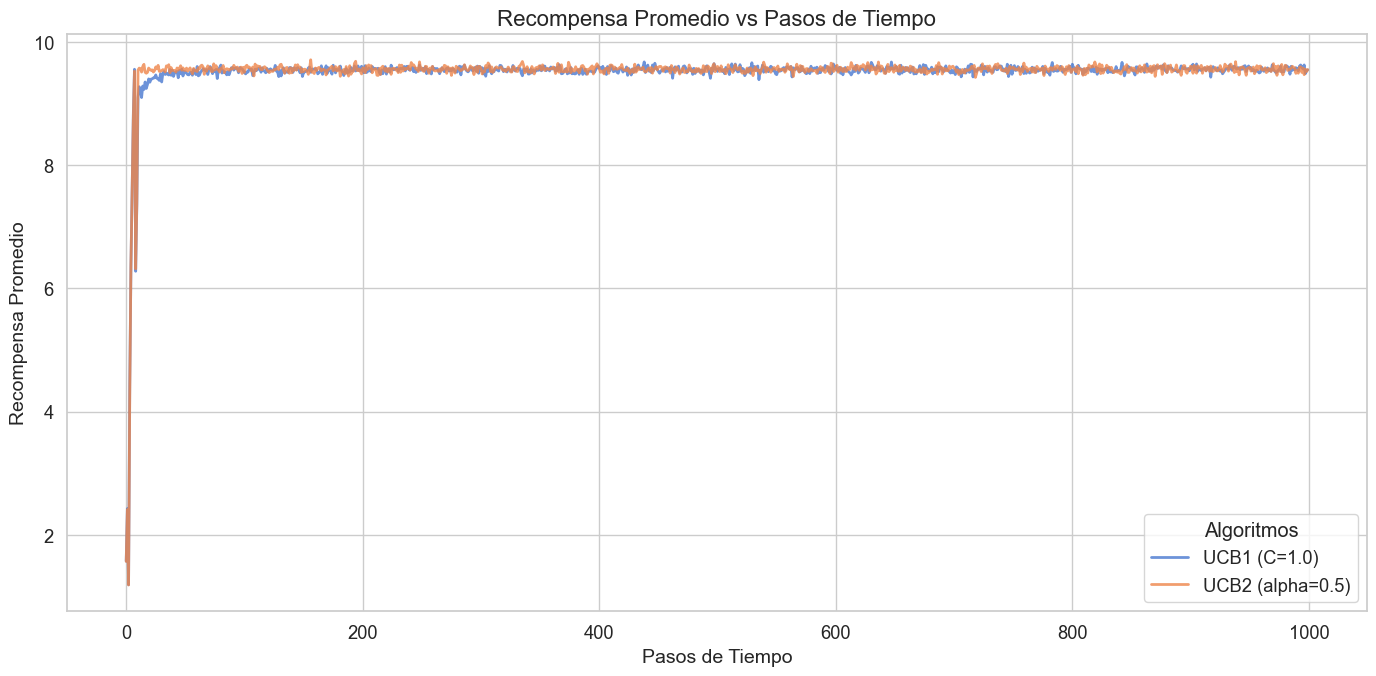

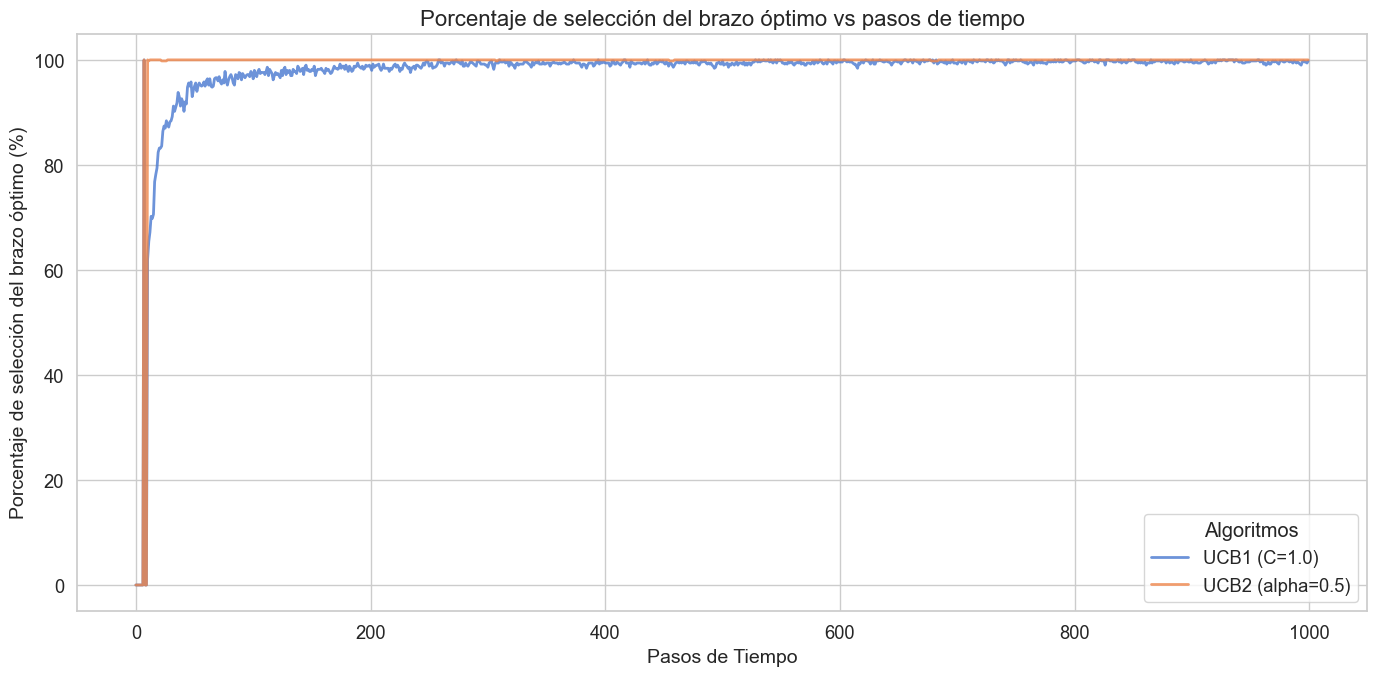

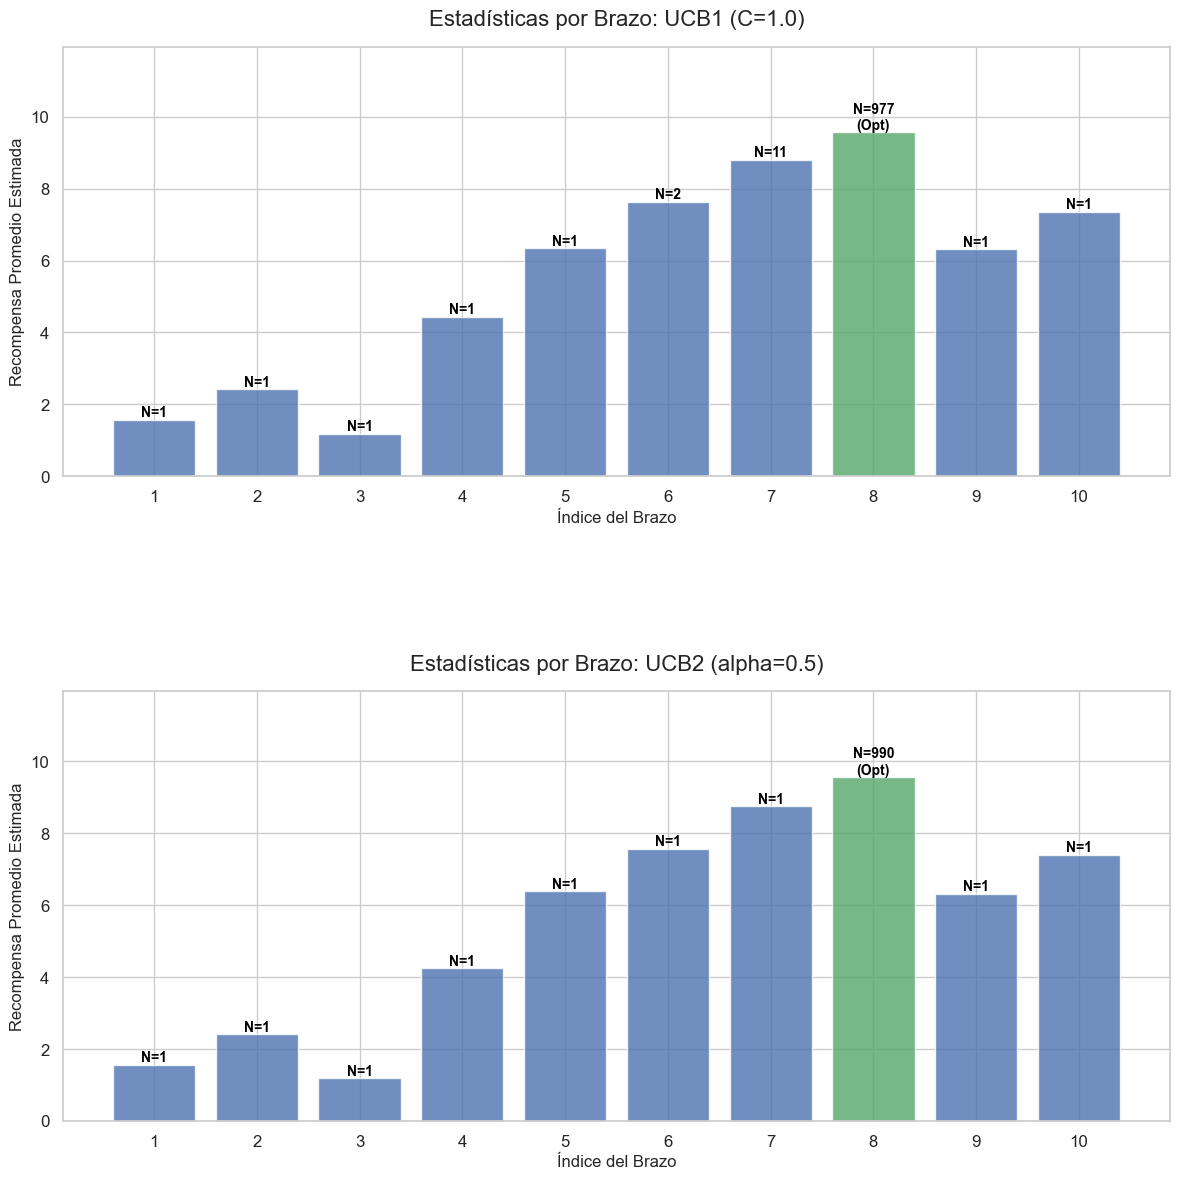

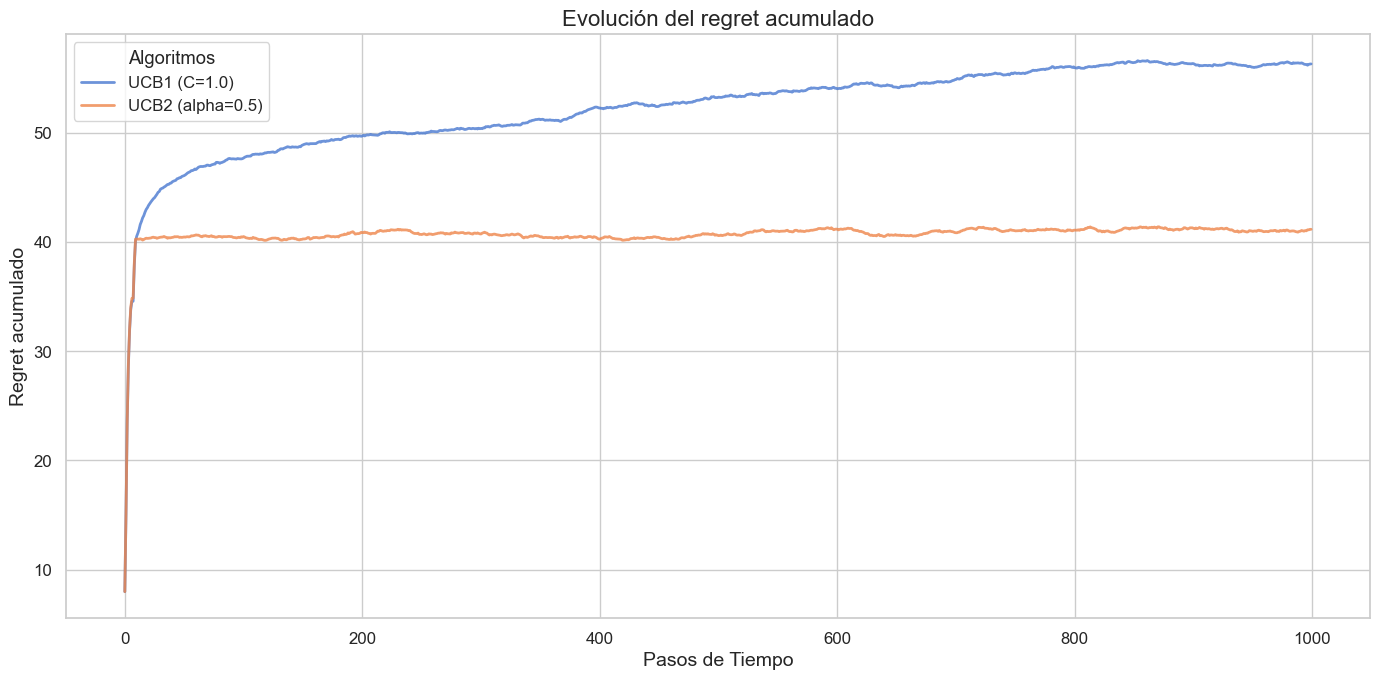

In [6]:
bandit = Bandit(arms=ArmNormal.generate_arms(k, mu_min=1.0, mu_max=10, sigma=1.0))
# bandit = Bandit(arms=ArmBernoulli.generate_arms(k, scale = 10))  
# bandit = Bandit(arms=ArmBinomial.generate_arms(k, n=10, scale = 1))
print(bandit)

# Obtiene el brazo óptimo para pasarlo a la gráfica
optimal_arm_index = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm_index + 1} with expected reward={bandit.get_expected_value(optimal_arm_index)}")

# Algoritmos para comparar
algorithms = [
                UCB1(k=k, c=1.0), 
                UCB2(k=k, alpha=0.5), 
            ]

# Ejecuta el experimento y obtiene las recompensas promedio y selecciones óptimas
rewards, optimal_selections, arms_stats, regret_accumulated = run_experiment(bandit, algorithms, steps, runs)

# Genera las gráficas
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_arm_statistics(arms_stats, algorithms, optimal_arm_index)
plot_regret(steps, regret_accumulated, algorithms)

### Experimento 2: Distribución Bernoulli

Bandit with 10 arms: ArmBernoulli(p=0.14), ArmBernoulli(p=0.34), ArmBernoulli(p=0.73), ArmBernoulli(p=0.15), ArmBernoulli(p=0.19), ArmBernoulli(p=0.31), ArmBernoulli(p=0.85), ArmBernoulli(p=0.26), ArmBernoulli(p=0.84), ArmBernoulli(p=0.81)
Optimal arm: 7 with expected reward=8.505


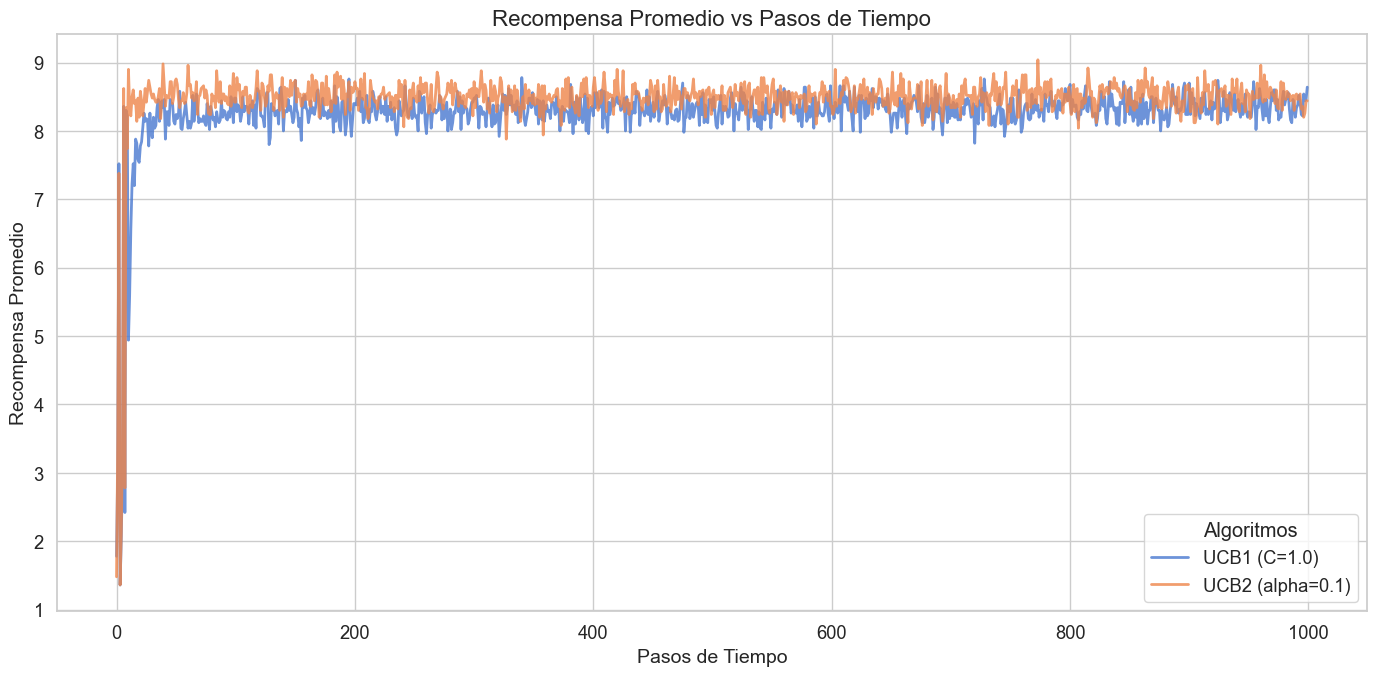

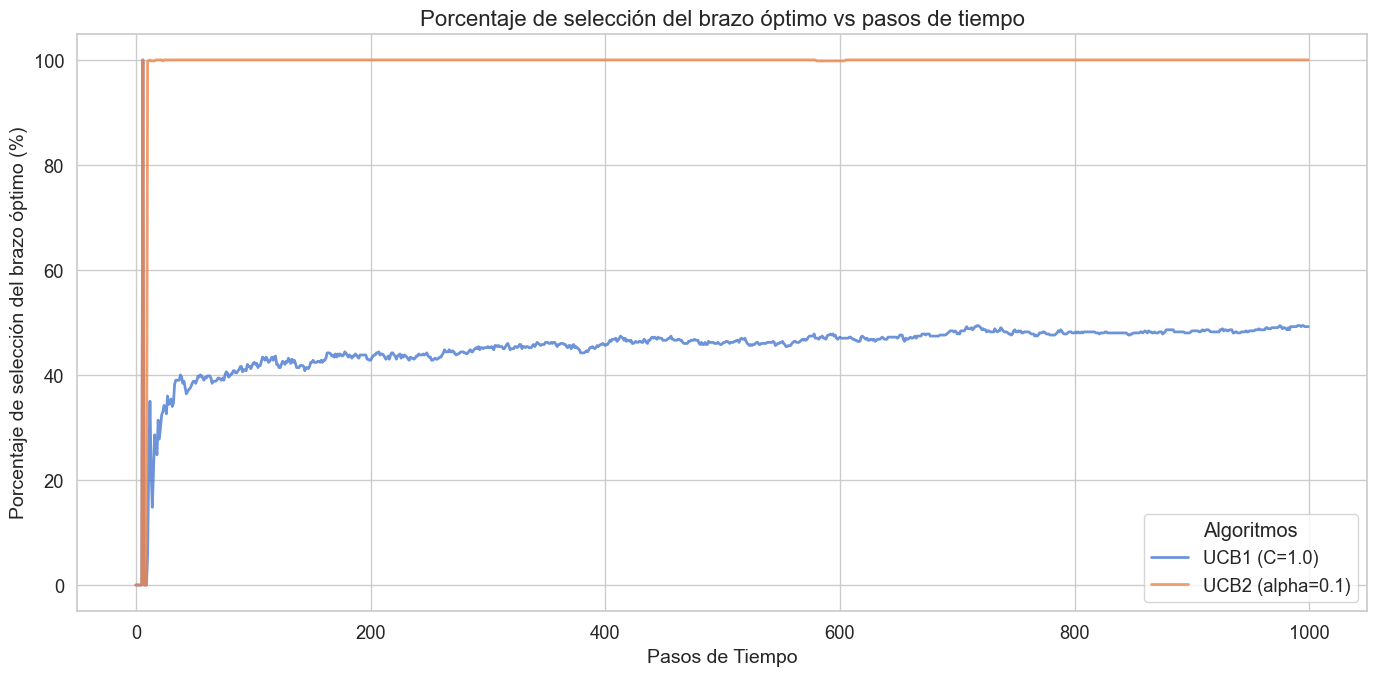

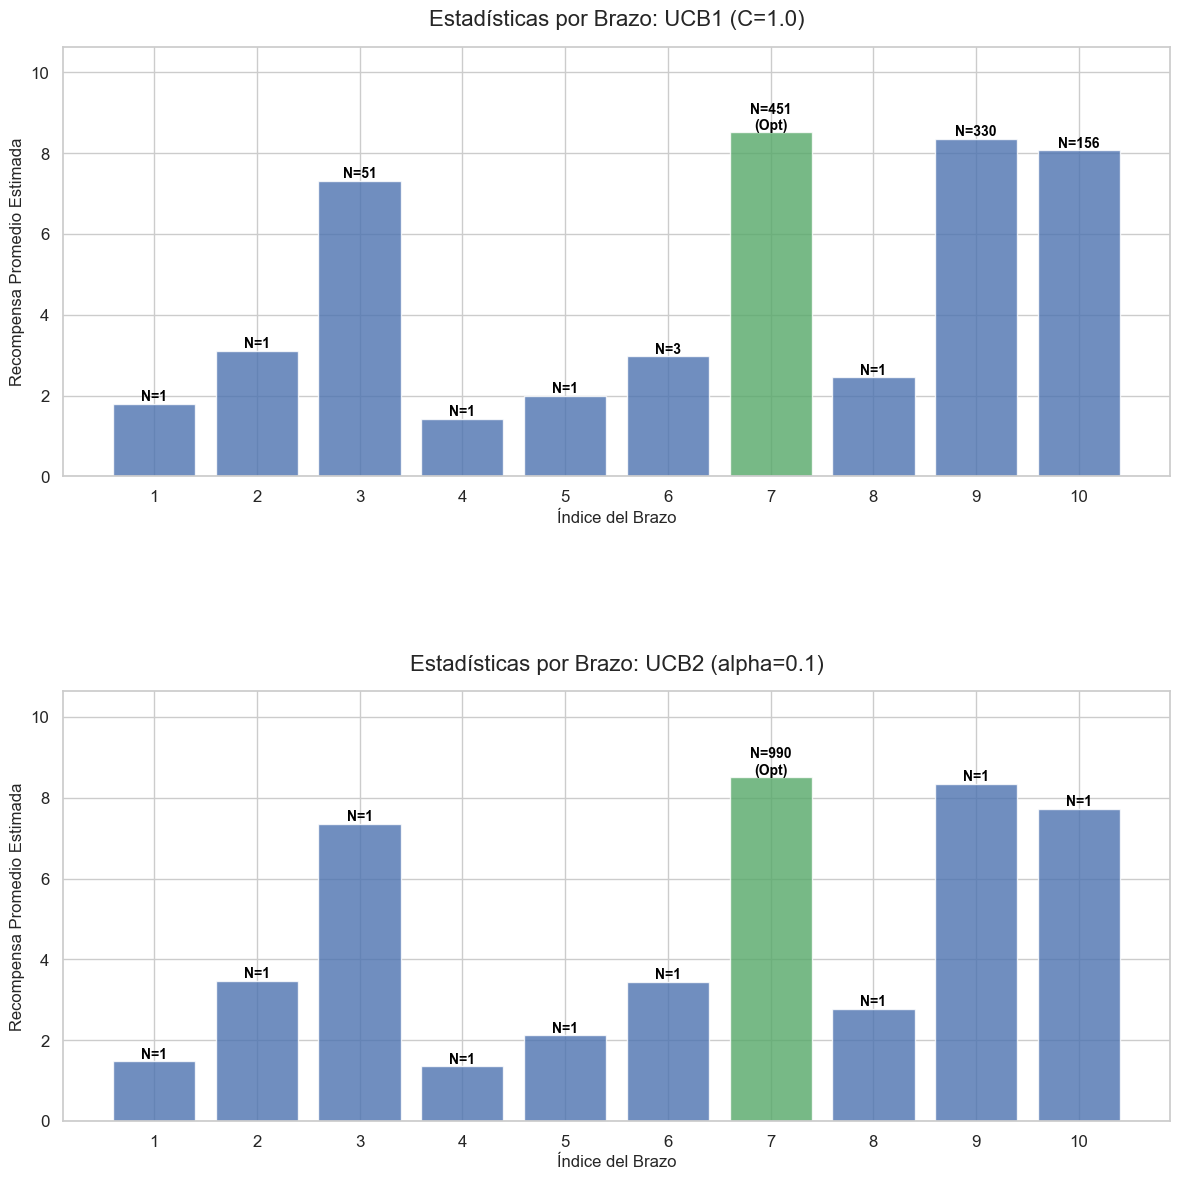

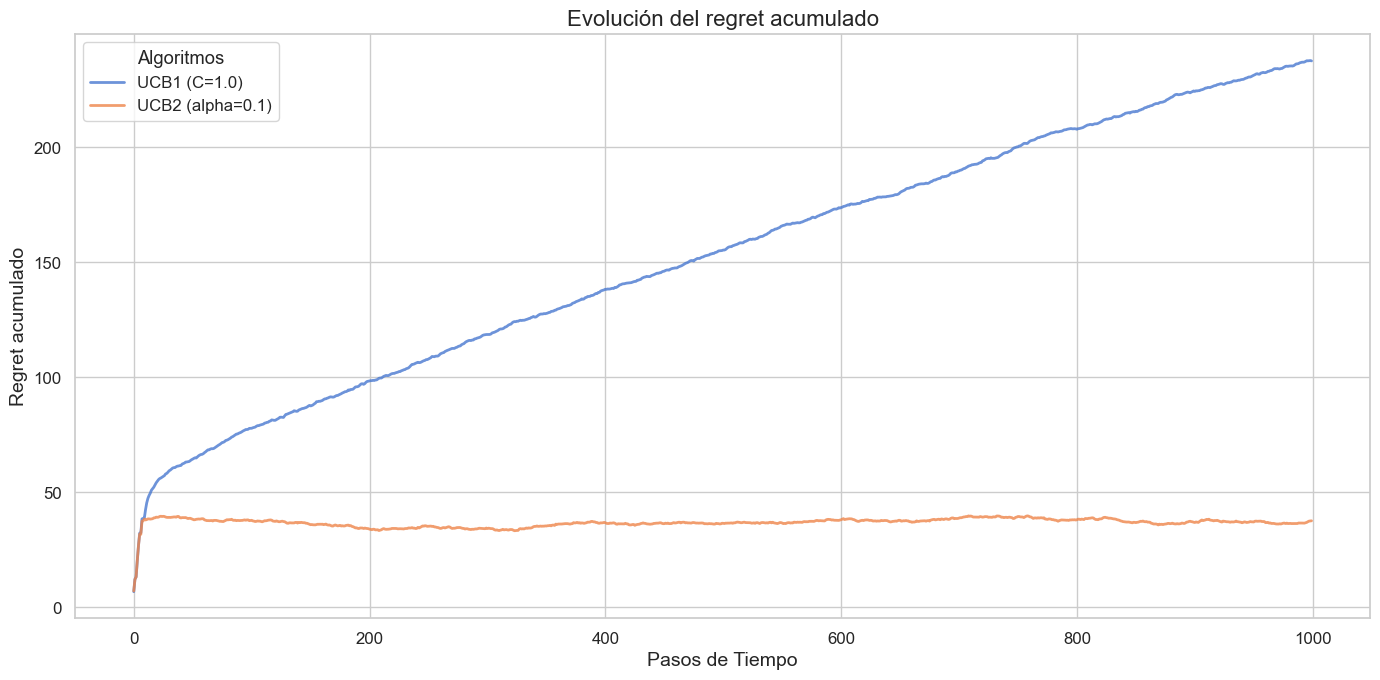

In [7]:
bandit = Bandit(arms=ArmBernoulli.generate_arms(k, scale = 10))  
# bandit = Bandit(arms=ArmBinomial.generate_arms(k, n=10, scale = 1))
print(bandit)

# Obtiene el brazo óptimo para pasarlo a la gráfica
optimal_arm_index = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm_index + 1} with expected reward={bandit.get_expected_value(optimal_arm_index)}")

# Algoritmos para comparar
algorithms = [
                UCB1(k=k, c=1.0), 
                UCB2(k=k, alpha=0.1), 
            ]

# Ejecuta el experimento y obtiene las recompensas promedio y selecciones óptimas
rewards, optimal_selections, arms_stats, regret_accumulated = run_experiment(bandit, algorithms, steps, runs)

# Genera las gráficas
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_arm_statistics(arms_stats, algorithms, optimal_arm_index)
plot_regret(steps, regret_accumulated, algorithms)

### Experimento 3: Distribución binomial

Bandit with 10 arms: ArmBinomial(n=10, p=0.87, scale=1), ArmBinomial(n=10, p=0.93, scale=1), ArmBinomial(n=10, p=0.58, scale=1), ArmBinomial(n=10, p=0.45, scale=1), ArmBinomial(n=10, p=0.97, scale=1), ArmBinomial(n=10, p=0.29, scale=1), ArmBinomial(n=10, p=0.11, scale=1), ArmBinomial(n=10, p=0.21, scale=1), ArmBinomial(n=10, p=0.18, scale=1), ArmBinomial(n=10, p=0.94, scale=1)
Optimal arm: 5 with expected reward=9.726


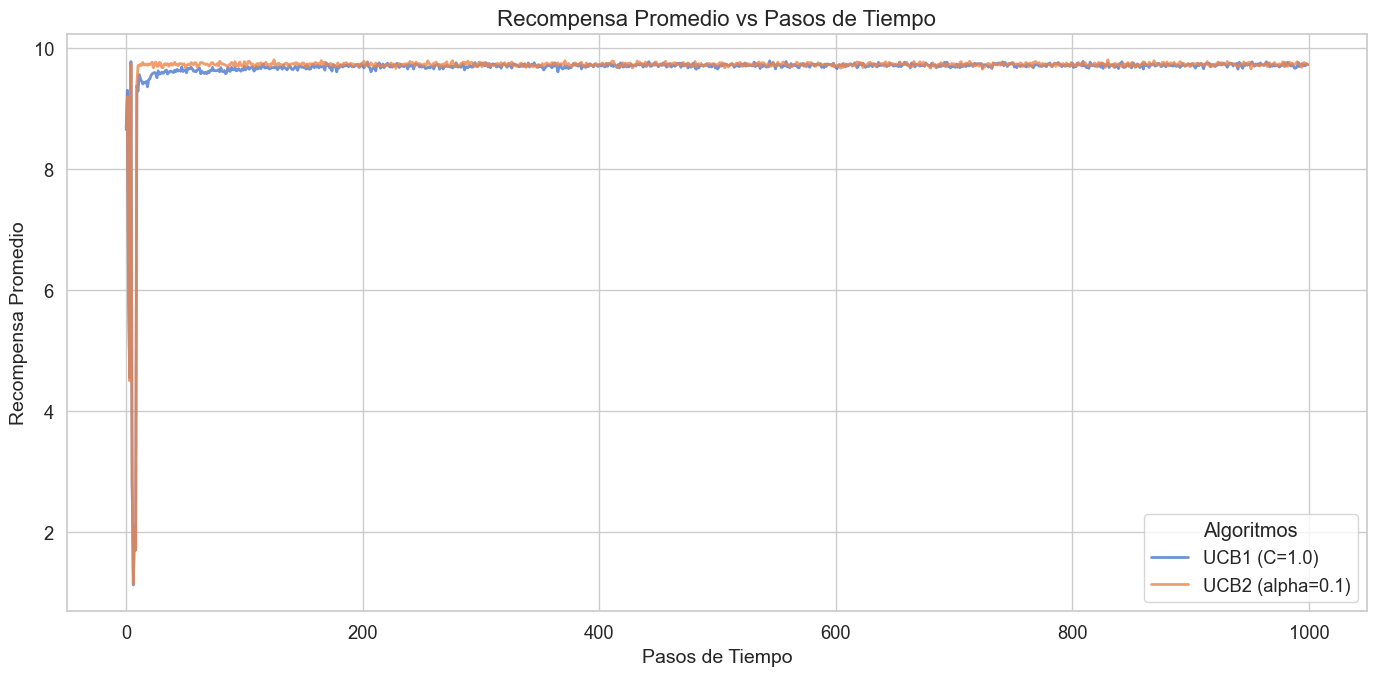

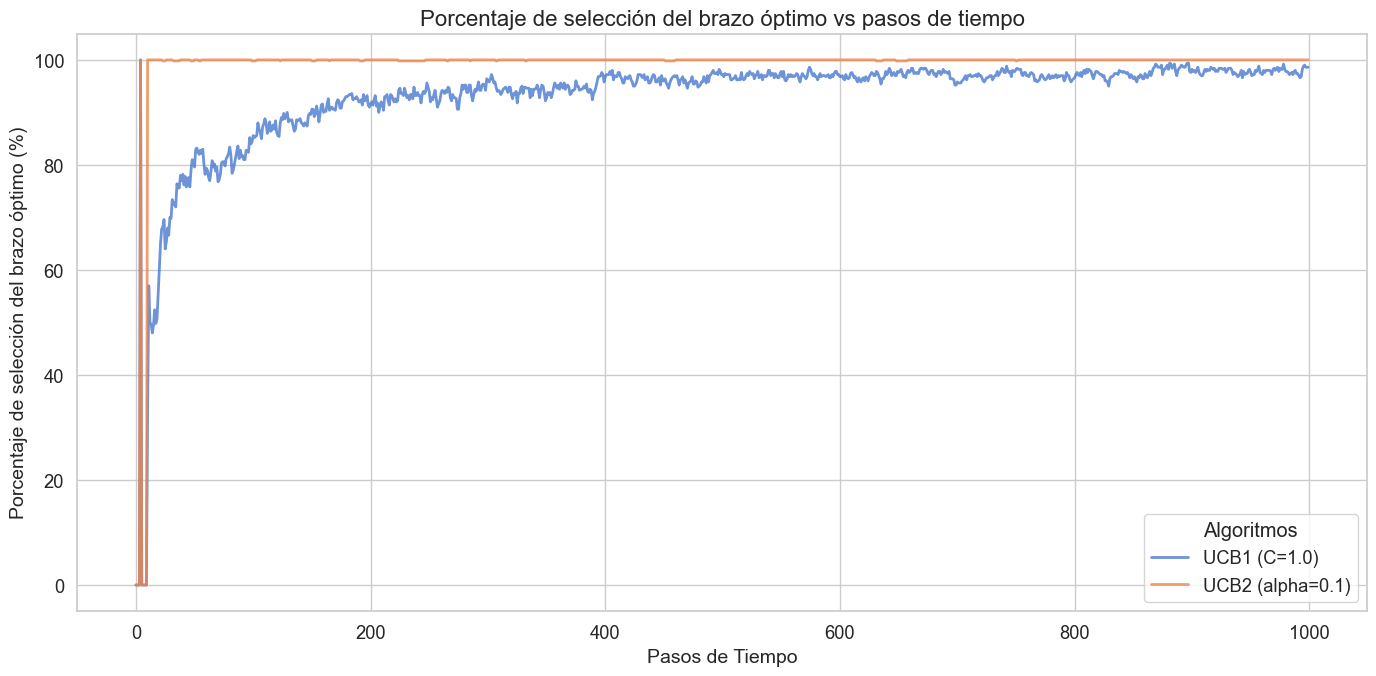

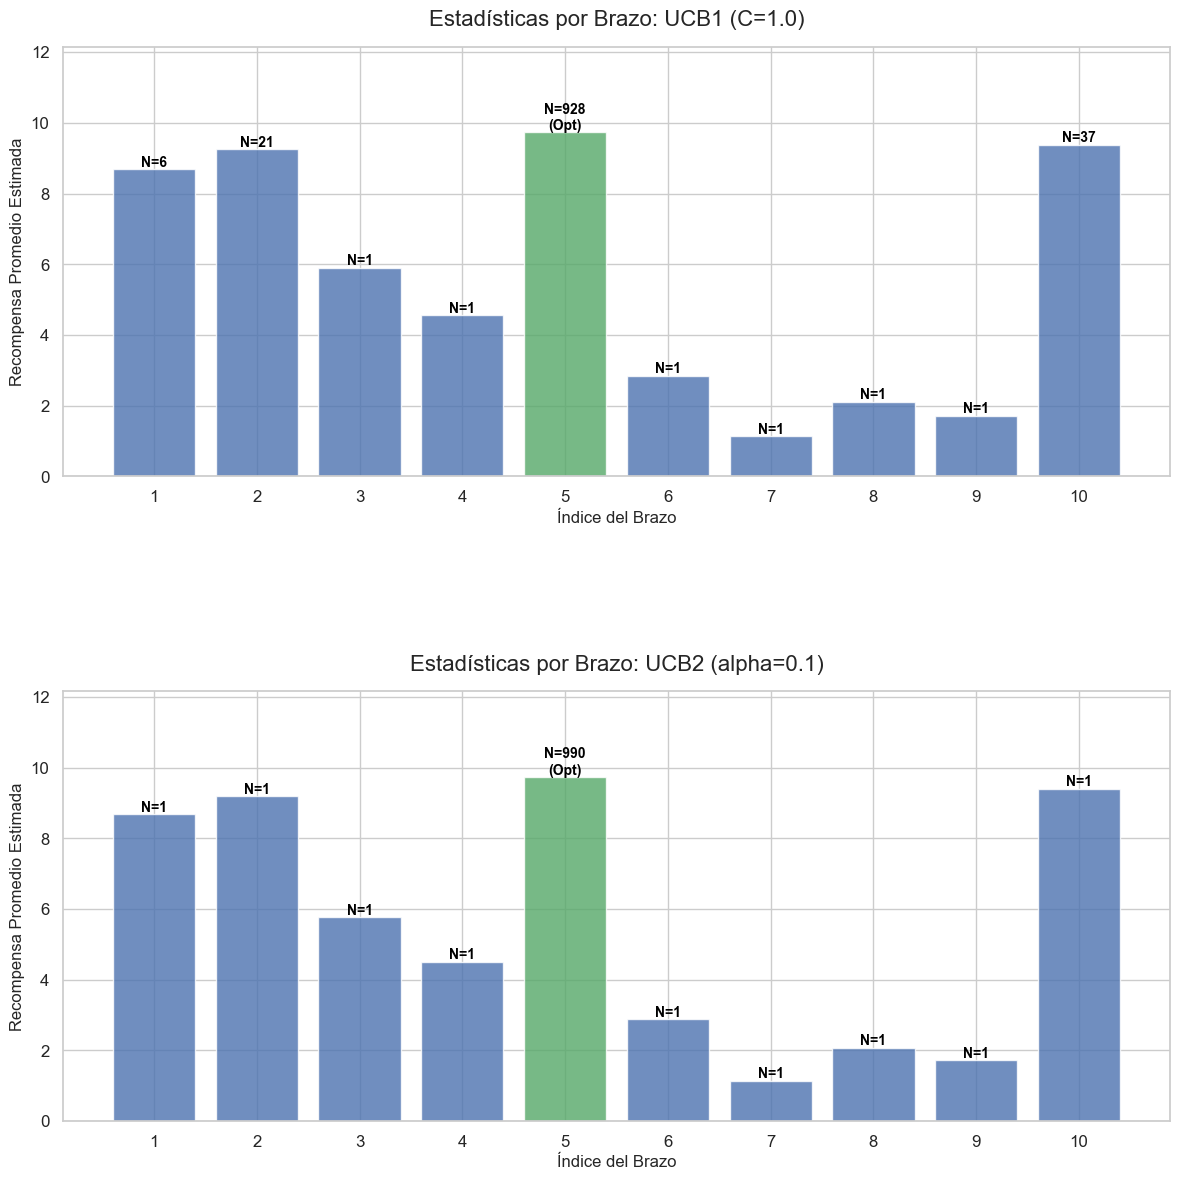

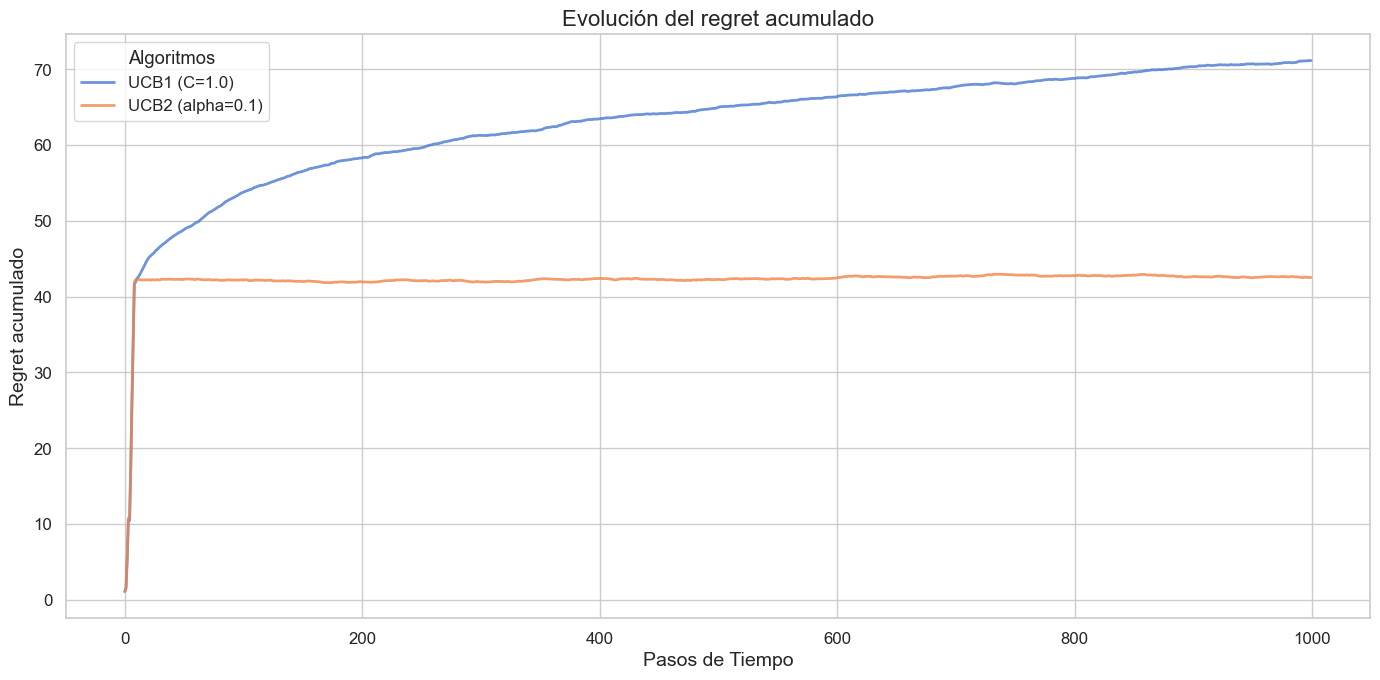

In [8]:
bandit = Bandit(arms=ArmBinomial.generate_arms(k, n=10, scale = 1))
print(bandit)

# Obtiene el brazo óptimo para pasarlo a la gráfica
optimal_arm_index = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm_index + 1} with expected reward={bandit.get_expected_value(optimal_arm_index)}")

# Algoritmos para comparar
algorithms = [
                UCB1(k=k, c=1.0), 
                UCB2(k=k, alpha=0.1), 
            ]

# Ejecuta el experimento y obtiene las recompensas promedio y selecciones óptimas
rewards, optimal_selections, arms_stats, regret_accumulated = run_experiment(bandit, algorithms, steps, runs)

# Genera las gráficas
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_arm_statistics(arms_stats, algorithms, optimal_arm_index)
plot_regret(steps, regret_accumulated, algorithms)